# Cognifyz Technologies - Data Analysis Internship
## Level 2

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import combinations
warnings.filterwarnings("ignore")

df = pd.read_csv("Dataset_.csv", encoding="utf-8-sig")
total = len(df)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 9551 rows, 21 columns


---
## Task 1 - Restaurant Ratings
**Objective:** Analyze the distribution of aggregate ratings, determine the most common rating range, and calculate average votes.

In [1]:
bins = [0, 1, 2, 3, 3.5, 4, 4.5, 5]
rlabels = ["0-1", "1-2", "2-3", "3-3.5", "3.5-4", "4-4.5", "4.5-5"]
df["Rating Range"] = pd.cut(df["Aggregate rating"], bins=bins, labels=rlabels, include_lowest=True)
rating_dist = df["Rating Range"].value_counts().reindex(rlabels)
avg_votes = df["Votes"].mean()

print(f"Most Common Rating Range: {rating_dist.idxmax()} ({rating_dist.max()} restaurants)")
print(f"Average Votes: {avg_votes:.2f}  |  Median: {df['Votes'].median():.0f}  |  Max: {df['Votes'].max()}")
print("\nRating Distribution:")
for r, c in rating_dist.items():
    print(f"  {r}: {c} ({c/total*100:.2f}%)")

Most Common Rating Range: 3-3.5 (2502 restaurants)
Average Votes: 156.91  |  Median: 31  |  Max: 10934

Rating Distribution:
  0-1: 2148 (22.49%)
  1-2: 10 (0.10%)
  2-3: 1891 (19.80%)
  3-3.5: 2502 (26.20%)
  3.5-4: 1886 (19.75%)
  4-4.5: 908 (9.51%)
  4.5-5: 206 (2.16%)


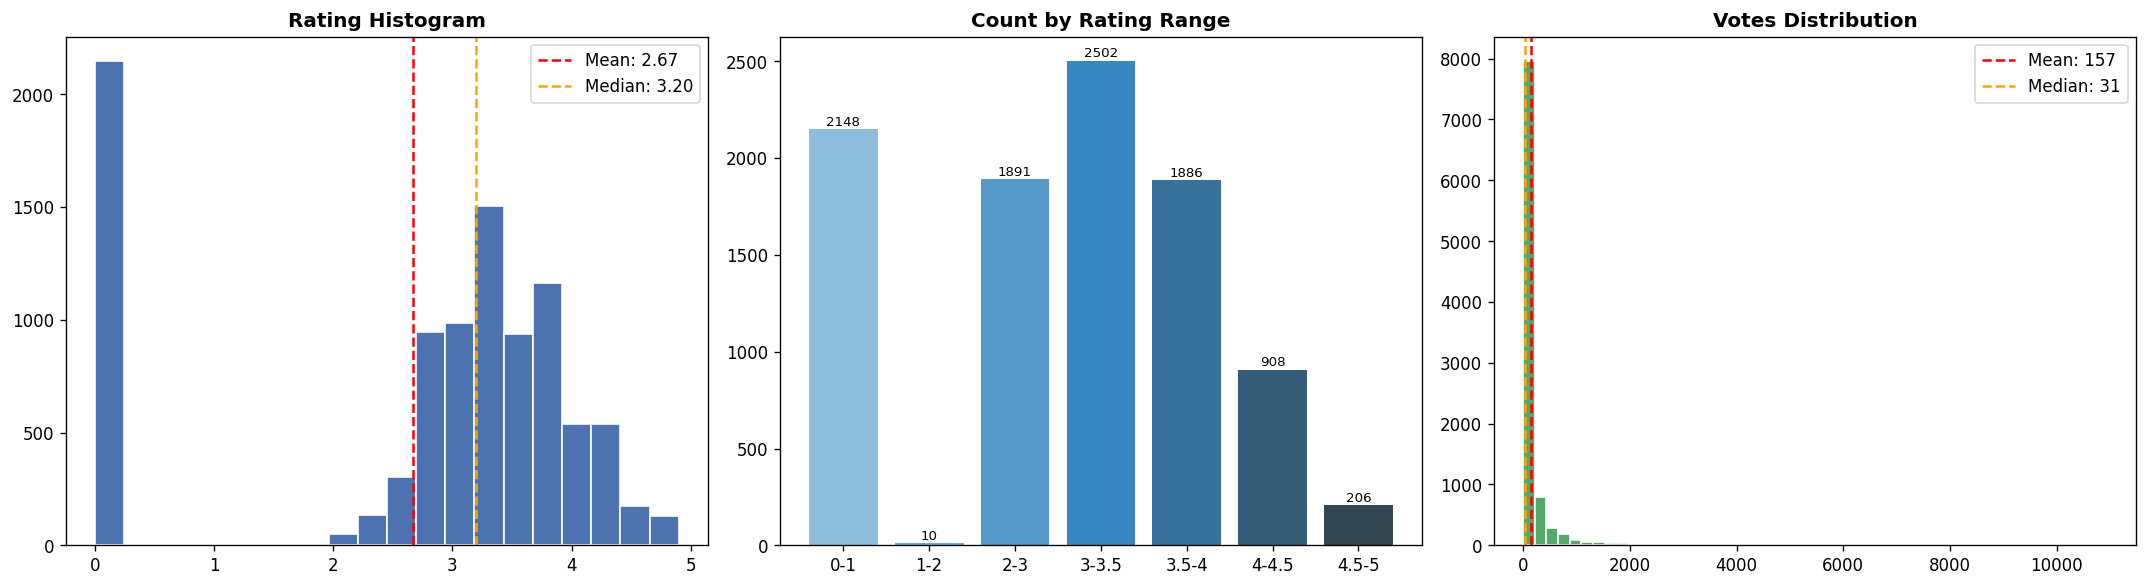

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df["Aggregate rating"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["Aggregate rating"].mean(), color="red", linestyle="--", label=f"Mean: {df['Aggregate rating'].mean():.2f}")
axes[0].axvline(df["Aggregate rating"].median(), color="orange", linestyle="--", label=f"Median: {df['Aggregate rating'].median():.2f}")
axes[0].set_title("Rating Histogram", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Count"); axes[0].legend()
bars = axes[1].bar(rating_dist.index, rating_dist.values, color=sns.color_palette("Blues_d", 7))
axes[1].set_title("Count by Rating Range", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rating Range"); axes[1].set_ylabel("Count")
for bar, val in zip(bars, rating_dist.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(val), ha="center", fontsize=8)
axes[2].hist(df["Votes"], bins=50, color="#55A868", edgecolor="white")
axes[2].axvline(avg_votes, color="red", linestyle="--", label=f"Mean: {avg_votes:.0f}")
axes[2].axvline(df["Votes"].median(), color="orange", linestyle="--", label=f"Median: {df['Votes'].median():.0f}")
axes[2].set_title("Votes Distribution", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Votes"); axes[2].set_ylabel("Count"); axes[2].legend()
plt.tight_layout()
plt.show()

---
## Task 2 - Cuisine Combination
**Objective:** Identify the most common cuisine combinations and determine if certain combinations tend to have higher ratings.

In [1]:
dfc = df.dropna(subset=["Cuisines"])
combo_counts = {}
combo_ratings = {}
for _, row in dfc.iterrows():
    cuisines = [c.strip() for c in row["Cuisines"].split(",")]
    if len(cuisines) < 2:
        continue
    for combo in combinations(sorted(cuisines), 2):
        key = " + ".join(combo)
        combo_counts[key] = combo_counts.get(key, 0) + 1
        combo_ratings.setdefault(key, []).append(row["Aggregate rating"])

combo_df = pd.DataFrame({
    "Combination": list(combo_counts.keys()),
    "Count": list(combo_counts.values()),
    "Avg Rating": [round(sum(v)/len(v), 2) for v in combo_ratings.values()]
}).sort_values("Count", ascending=False)

top10 = combo_df.head(10)
top10_rated = combo_df[combo_df["Count"] >= 50].sort_values("Avg Rating", ascending=False).head(10)

print("Top 5 Most Common Combinations:")
print(top10[["Combination","Count","Avg Rating"]].head().to_string(index=False))
print("\nTop 5 Highest Rated (min 50 restaurants):")
print(top10_rated[["Combination","Count","Avg Rating"]].head().to_string(index=False))

Top 5 Most Common Combinations:
  Chinese + North Indian: 1784 (Avg Rating: 2.7)
  Mughlai + North Indian: 832 (Avg Rating: 2.76)
  Fast Food + North Indian: 485 (Avg Rating: 2.7)
  Continental + North Indian: 468 (Avg Rating: 3.41)
  Chinese + Fast Food: 466 (Avg Rating: 2.58)

Top 5 Highest Rated (min 50 restaurants):
  Cafe + Desserts: 55 (Avg Rating: 3.89)
  European + North Indian: 63 (Avg Rating: 3.88)
  American + Continental: 50 (Avg Rating: 3.86)
  Asian + Continental: 67 (Avg Rating: 3.85)
  Cafe + Italian: 157 (Avg Rating: 3.85)


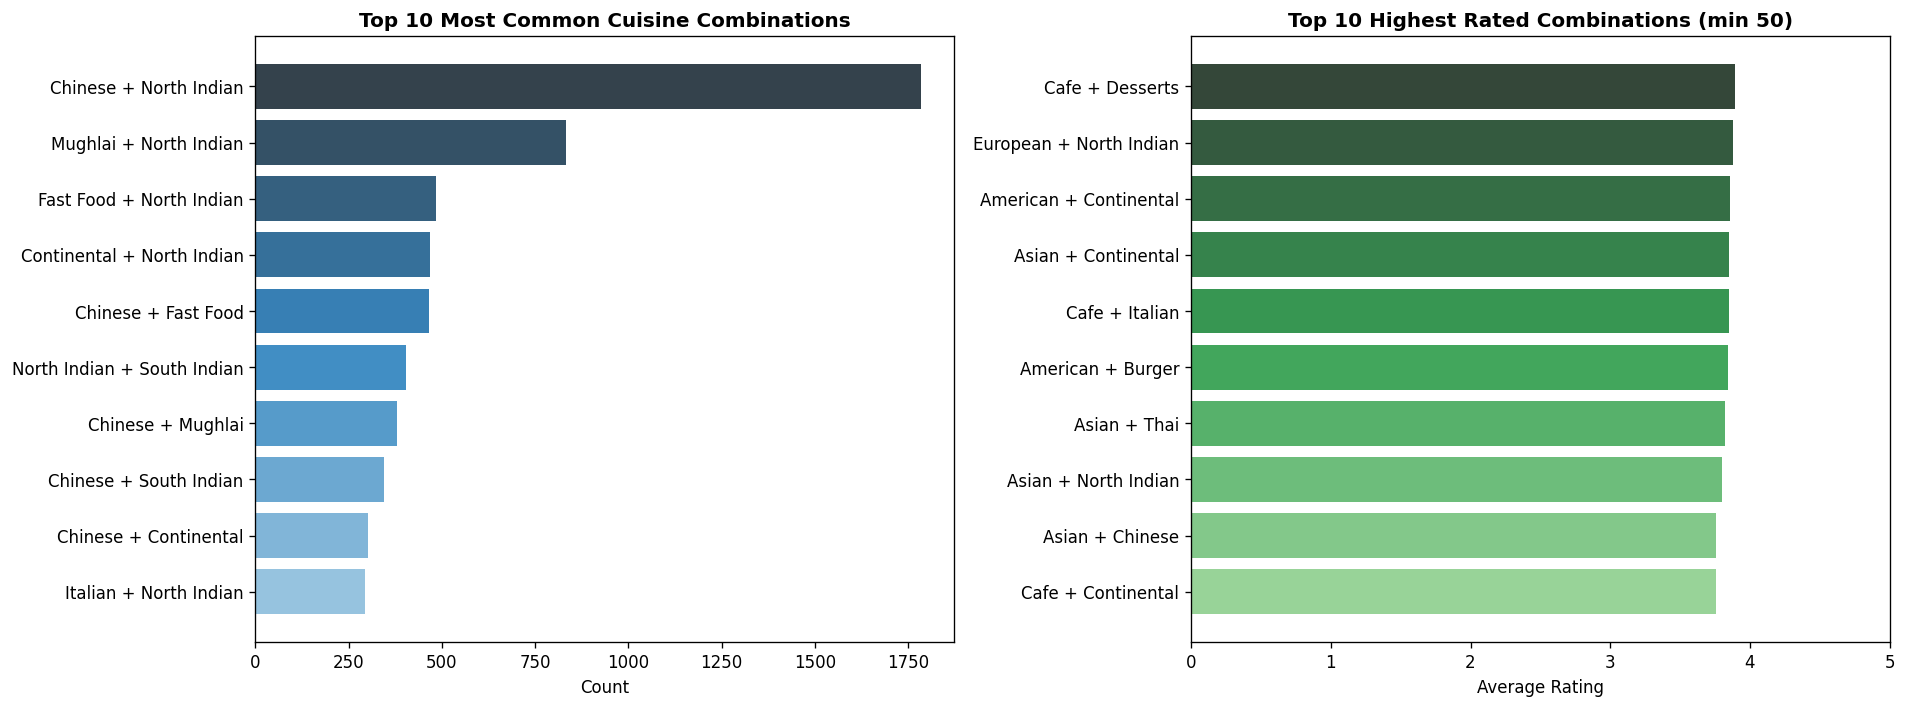

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top10["Combination"][::-1], top10["Count"][::-1], color=sns.color_palette("Blues_d", 10))
axes[0].set_title("Top 10 Most Common Cuisine Combinations", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Restaurants")
axes[1].barh(top10_rated["Combination"][::-1], top10_rated["Avg Rating"][::-1], color=sns.color_palette("Greens_d", 10))
axes[1].set_title("Top 10 Highest Rated Combinations (min 50)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Average Rating"); axes[1].set_xlim(0, 5)
plt.tight_layout()
plt.show()

---
## Task 3 - Geographic Analysis
**Objective:** Plot restaurant locations using coordinates and identify patterns or clusters.

In [1]:
dfg = df.dropna(subset=["Latitude", "Longitude"])
dfg = dfg[(dfg["Latitude"] != 0) & (dfg["Longitude"] != 0)]
print(f"Restaurants with valid coordinates: {len(dfg)}")
print(f"Lat range: {dfg['Latitude'].min():.2f} to {dfg['Latitude'].max():.2f}")
print(f"Lon range: {dfg['Longitude'].min():.2f} to {dfg['Longitude'].max():.2f}")

Restaurants with valid coordinates: 9052
Lat range: -41.33 to 55.98
Lon range: -157.95 to 174.83


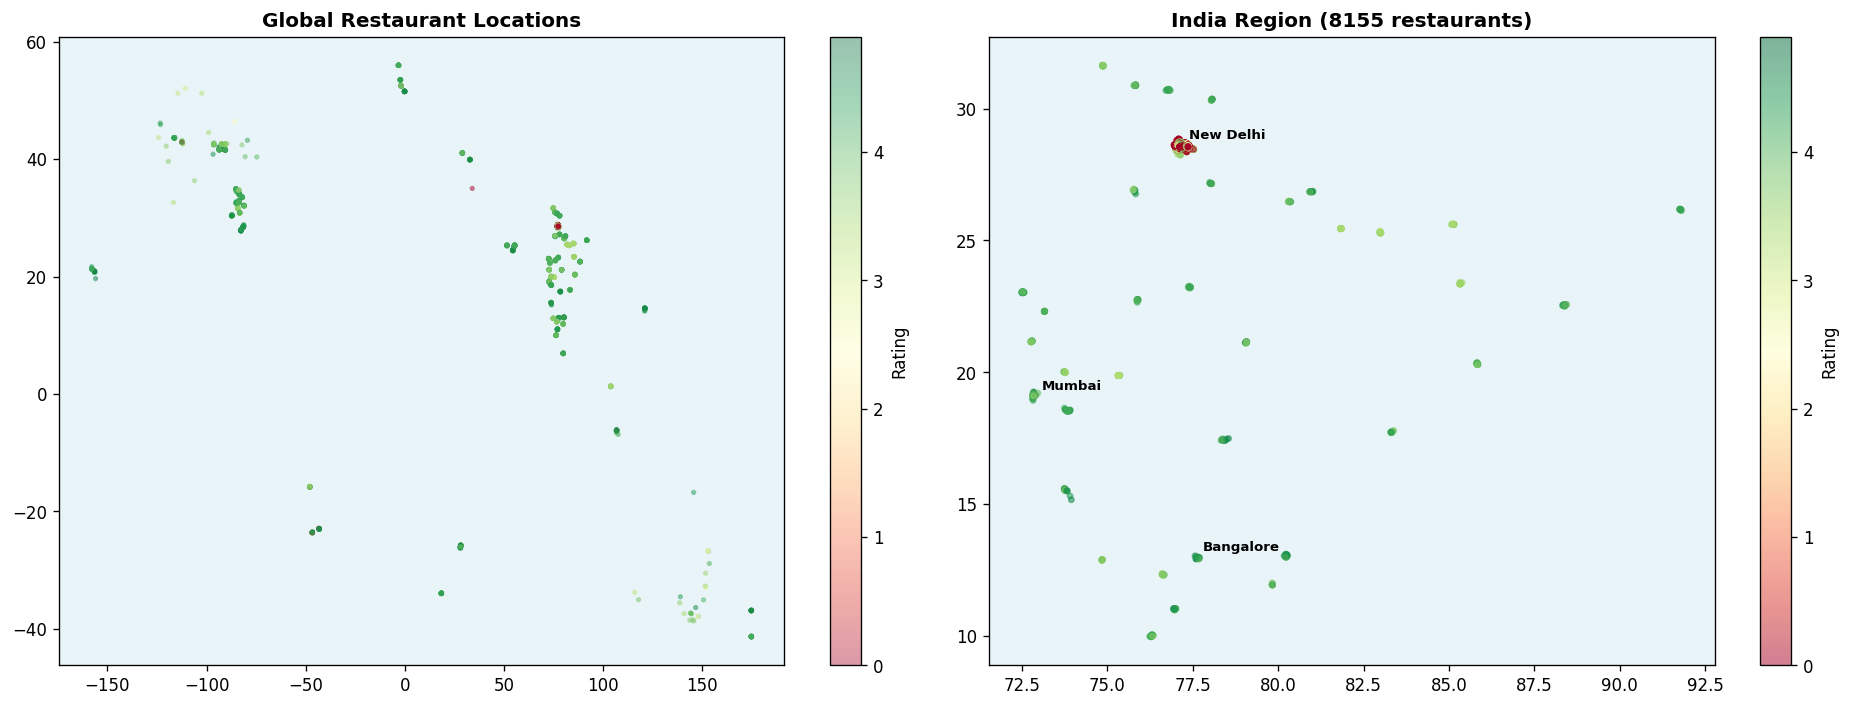

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(dfg["Longitude"], dfg["Latitude"], c=dfg["Aggregate rating"], cmap="RdYlGn", alpha=0.4, s=5)
plt.colorbar(sc, ax=axes[0], label="Rating")
axes[0].set_title("Global Restaurant Locations", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].set_facecolor("#e8f4f8")

india = dfg[(dfg["Latitude"]>=8)&(dfg["Latitude"]<=37)&(dfg["Longitude"]>=68)&(dfg["Longitude"]<=98)]
sc2 = axes[1].scatter(india["Longitude"], india["Latitude"], c=india["Aggregate rating"], cmap="RdYlGn", alpha=0.5, s=10)
plt.colorbar(sc2, ax=axes[1], label="Rating")
axes[1].set_title(f"India Region ({len(india)} restaurants)", fontsize=12, fontweight="bold")
axes[1].set_facecolor("#e8f4f8")
for city, lat, lon in [("New Delhi",28.6,77.2),("Mumbai",19.1,72.9),("Bangalore",12.97,77.6)]:
    axes[1].annotate(city, (lon,lat), fontsize=8, fontweight="bold", xytext=(4,4), textcoords="offset points")
plt.tight_layout()
plt.show()

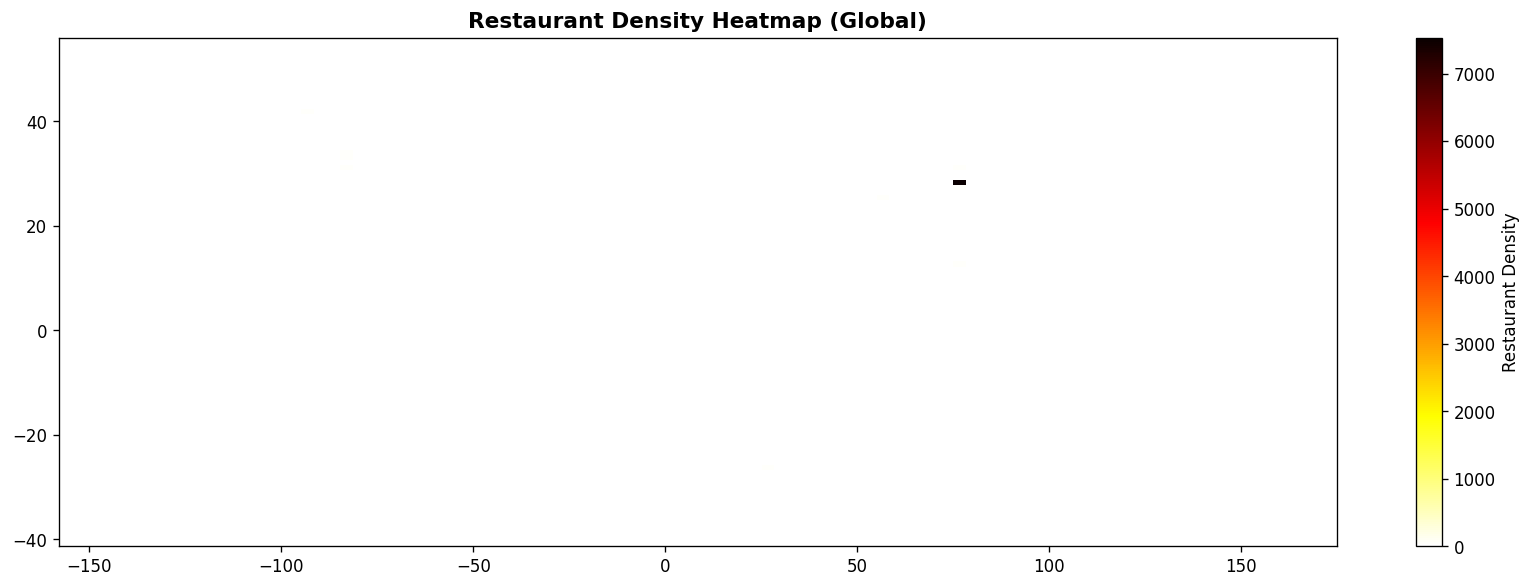

In [1]:
fig, ax = plt.subplots(figsize=(14, 5))
h = ax.hist2d(dfg["Longitude"], dfg["Latitude"], bins=100, cmap="hot_r")
plt.colorbar(h[3], ax=ax, label="Restaurant Density")
ax.set_title("Restaurant Density Heatmap (Global)", fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

---
## Task 4 - Restaurant Chains
**Objective:** Identify restaurant chains and analyze their ratings and popularity.

In [1]:
name_counts = df["Restaurant Name"].value_counts()
chains = name_counts[name_counts > 1]
chain_df = df[df["Restaurant Name"].isin(chains.index)]
chain_stats = chain_df.groupby("Restaurant Name").agg(
    Outlets=("Restaurant Name", "count"),
    Avg_Rating=("Aggregate rating", "mean"),
    Total_Votes=("Votes", "sum")
).round(2).sort_values("Outlets", ascending=False)

print(f"Total chains identified: {len(chains)}")
print(f"Restaurants belonging to chains: {len(chain_df)}")
print("\nTop 10 Chains by Outlets:")
print(chain_stats.head(10).to_string())

Total chains identified: 734
Restaurants belonging to chains: 2839

Top 10 Chains by Outlets:
                  Outlets  Avg_Rating  Total_Votes
Restaurant Name                                   
Cafe Coffee Day        83        2.42         2428
Domino's Pizza         79        2.74         6643
Subway                 63        2.91         6124
Green Chick Chop       51        2.67          964
McDonald's             48        3.34         5291
Keventers              34        2.87         1263
Pizza Hut              30        3.32         4961
Giani                  29        2.69          854
Baskin Robbins         28        1.86          428
Barbeque Nation        26        4.35        28142


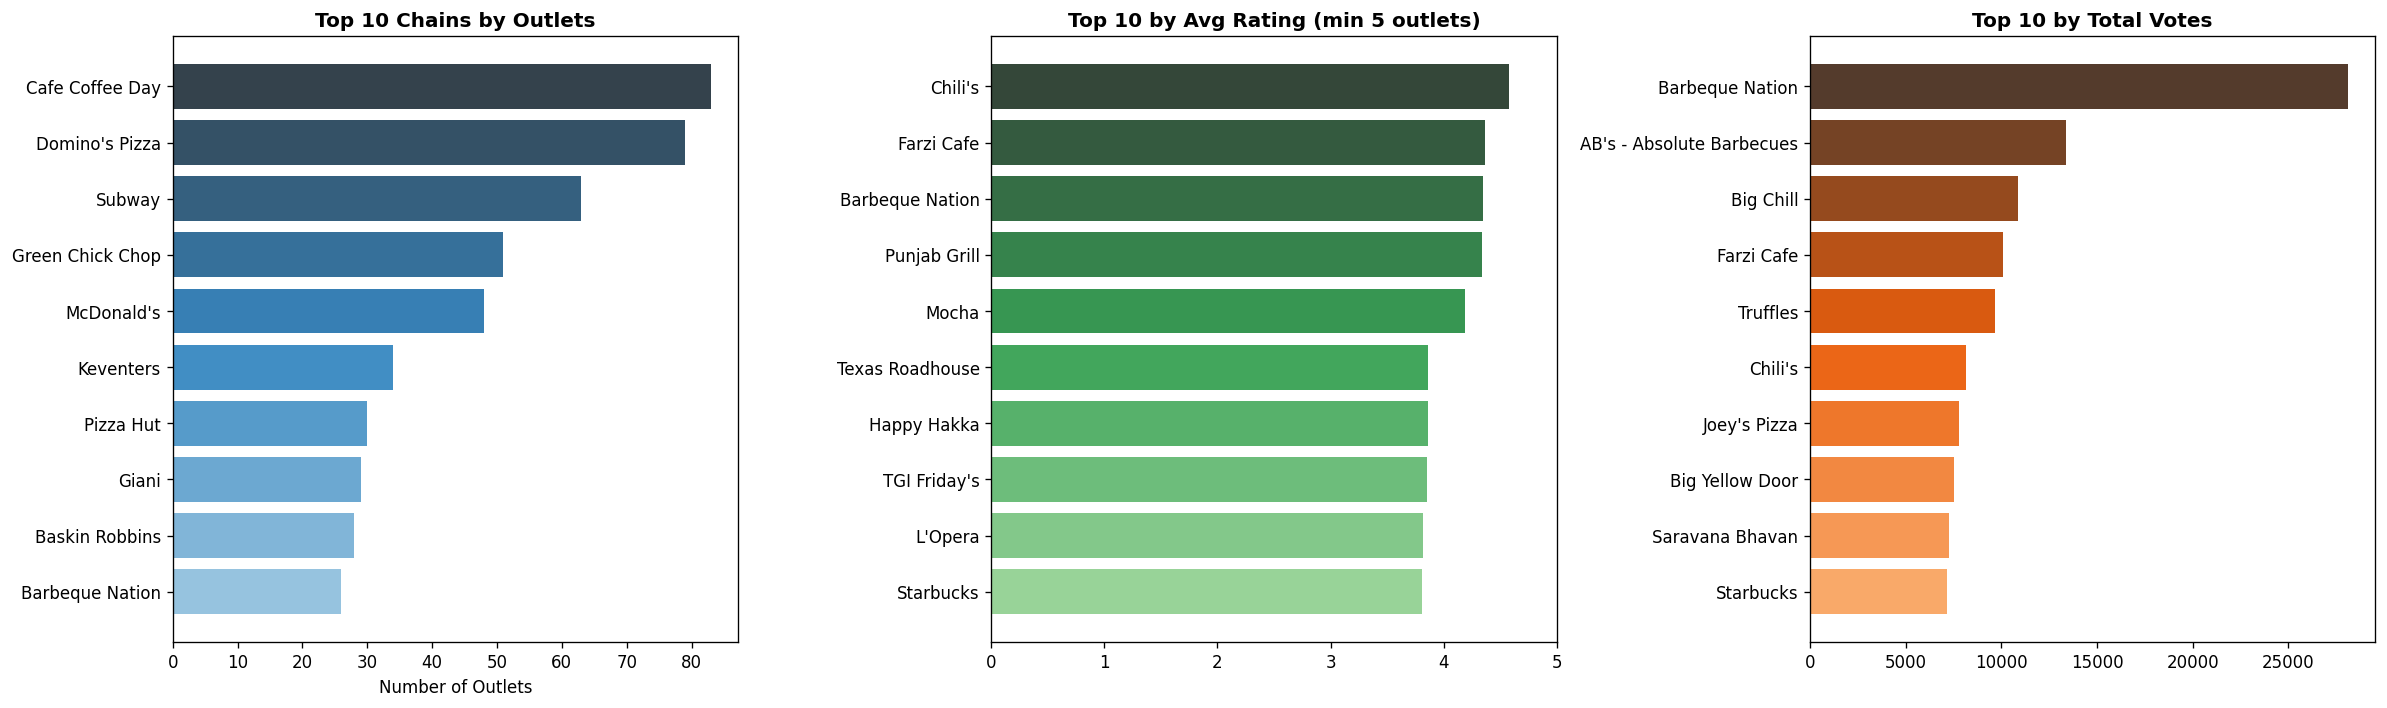

In [1]:
top10_o = chain_stats.head(10)
top10_r = chain_stats[chain_stats["Outlets"] >= 5].sort_values("Avg_Rating", ascending=False).head(10)
top10_v = chain_stats.sort_values("Total_Votes", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].barh(top10_o.index[::-1], top10_o["Outlets"][::-1], color=sns.color_palette("Blues_d", 10))
axes[0].set_title("Top 10 Chains by Outlets", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Outlets")

axes[1].barh(top10_r.index[::-1], top10_r["Avg_Rating"][::-1], color=sns.color_palette("Greens_d", 10))
axes[1].set_title("Top 10 by Avg Rating (min 5 outlets)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Average Rating"); axes[1].set_xlim(0, 5)

axes[2].barh(top10_v.index[::-1], top10_v["Total_Votes"][::-1], color=sns.color_palette("Oranges_d", 10))
axes[2].set_title("Top 10 by Total Votes", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Total Votes")
plt.tight_layout()
plt.show()